# ch203 — Limits Intuition

**Part VII: Calculus**

---

## 1. What a Limit Is

The **limit** of f(x) as x approaches a is the value that f(x) gets arbitrarily close to as x gets closer and closer to a — without necessarily reaching a.

$$\lim_{x \to a} f(x) = L$$

This reads: "as x approaches a, f(x) approaches L."

Key point: the limit is about the **approach**, not the value at the point. f(a) might not even be defined.

*(Limits underpin the definition of the derivative established in ch205. The difference quotient [f(x+h)-f(x)]/h requires h→0, which is a limit.)*

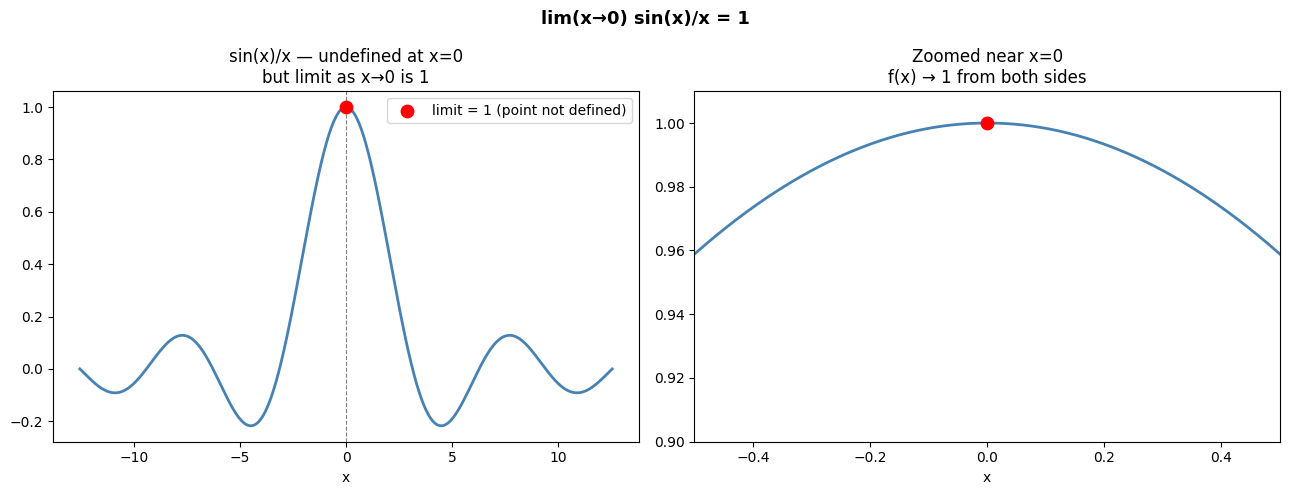

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Classic example: sin(x)/x as x -> 0
# The function is undefined at x=0, but the limit exists and equals 1

x_left  = np.linspace(-4*np.pi, -1e-6, 500)
x_right = np.linspace( 1e-6,  4*np.pi, 500)

f = lambda x: np.sin(x) / x

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Full view
axes[0].plot(x_left,  f(x_left),  color='steelblue', linewidth=2)
axes[0].plot(x_right, f(x_right), color='steelblue', linewidth=2)
axes[0].scatter([0], [1], color='red', zorder=6, s=80, label='limit = 1 (point not defined)')
axes[0].axvline(0, color='gray', linewidth=0.8, linestyle='--')
axes[0].set_title('sin(x)/x — undefined at x=0\nbut limit as x→0 is 1')
axes[0].set_xlabel('x')
axes[0].legend()

# Zoom near x=0
x_zoom = np.concatenate([np.linspace(-0.5, -1e-8, 200), np.linspace(1e-8, 0.5, 200)])
axes[1].plot(x_zoom, f(x_zoom), color='steelblue', linewidth=2)
axes[1].scatter([0], [1], color='red', zorder=6, s=80)
axes[1].set_xlim(-0.5, 0.5)
axes[1].set_ylim(0.9, 1.01)
axes[1].set_title('Zoomed near x=0\nf(x) → 1 from both sides')
axes[1].set_xlabel('x')

plt.suptitle('lim(x→0) sin(x)/x = 1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [2]:
# Numerically verify: approach 0 from both sides
print('Approaching x=0 from the RIGHT:')
for x in [0.5, 0.1, 0.01, 0.001, 1e-6, 1e-10]:
    val = np.sin(x) / x
    print(f'  x = {x:.2e}   sin(x)/x = {val:.10f}')

print()
print('Approaching x=0 from the LEFT:')
for x in [-0.5, -0.1, -0.01, -0.001, -1e-6, -1e-10]:
    val = np.sin(x) / x
    print(f'  x = {x:.2e}   sin(x)/x = {val:.10f}')

print()
print('Both sides converge to 1.0 — the limit exists.')

Approaching x=0 from the RIGHT:
  x = 5.00e-01   sin(x)/x = 0.9588510772
  x = 1.00e-01   sin(x)/x = 0.9983341665
  x = 1.00e-02   sin(x)/x = 0.9999833334
  x = 1.00e-03   sin(x)/x = 0.9999998333
  x = 1.00e-06   sin(x)/x = 1.0000000000
  x = 1.00e-10   sin(x)/x = 1.0000000000

Approaching x=0 from the LEFT:
  x = -5.00e-01   sin(x)/x = 0.9588510772
  x = -1.00e-01   sin(x)/x = 0.9983341665
  x = -1.00e-02   sin(x)/x = 0.9999833334
  x = -1.00e-03   sin(x)/x = 0.9999998333
  x = -1.00e-06   sin(x)/x = 1.0000000000
  x = -1.00e-10   sin(x)/x = 1.0000000000

Both sides converge to 1.0 — the limit exists.


## 2. When Limits Don't Exist

A limit fails to exist in three ways:
1. Left and right limits are different (jump discontinuity)
2. The function oscillates infinitely fast
3. The function goes to ±∞

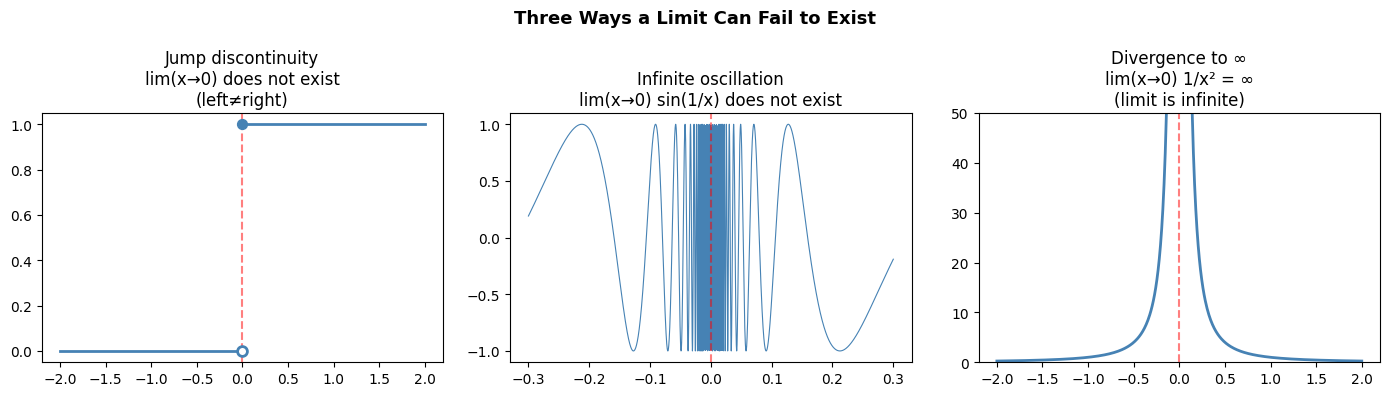

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Jump discontinuity: Heaviside step function
x = np.linspace(-2, 2, 500)
step = np.where(x < 0, 0.0, 1.0)
axes[0].plot(x[x < 0],  step[x < 0],  color='steelblue', linewidth=2)
axes[0].plot(x[x >= 0], step[x >= 0], color='steelblue', linewidth=2)
axes[0].scatter([0], [0], color='steelblue', s=50, zorder=6, facecolors='white', edgecolors='steelblue', linewidths=2)
axes[0].scatter([0], [1], color='steelblue', s=50, zorder=6)
axes[0].set_title('Jump discontinuity\nlim(x→0) does not exist\n(left≠right)')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.5)

# 2. Oscillation: sin(1/x)
x2_left  = np.linspace(-0.3, -1e-4, 5000)
x2_right = np.linspace( 1e-4,  0.3, 5000)
axes[1].plot(x2_left,  np.sin(1/x2_left),  color='steelblue', linewidth=0.8)
axes[1].plot(x2_right, np.sin(1/x2_right), color='steelblue', linewidth=0.8)
axes[1].set_title('Infinite oscillation\nlim(x→0) sin(1/x) does not exist')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.5)

# 3. Divergence: 1/x^2
x3_left  = np.linspace(-2, -0.05, 300)
x3_right = np.linspace( 0.05,  2, 300)
axes[2].plot(x3_left,  1/x3_left**2,  color='steelblue', linewidth=2)
axes[2].plot(x3_right, 1/x3_right**2, color='steelblue', linewidth=2)
axes[2].set_ylim(0, 50)
axes[2].set_title('Divergence to ∞\nlim(x→0) 1/x² = ∞\n(limit is infinite)')
axes[2].axvline(0, color='red', linestyle='--', alpha=0.5)

plt.suptitle('Three Ways a Limit Can Fail to Exist', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Limits at Infinity

We also care about behavior as x → ∞: what does a function approach as the input grows without bound?

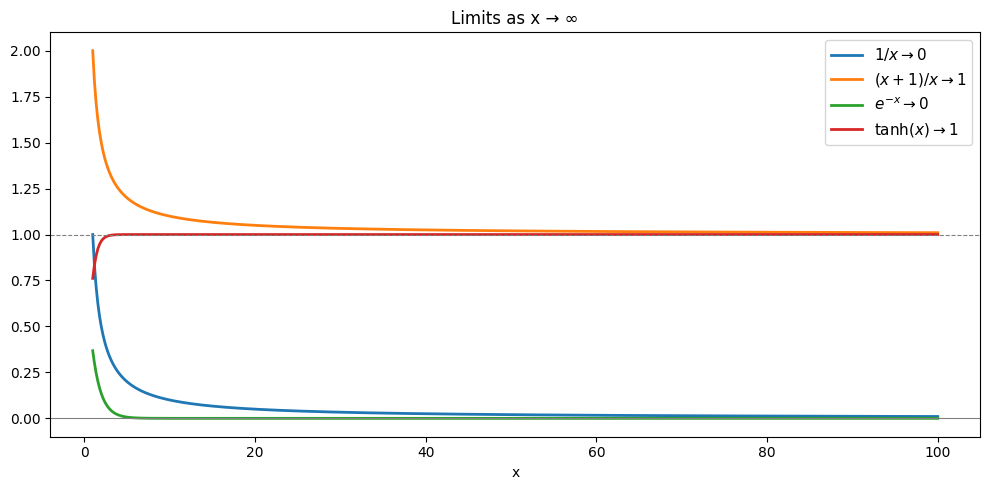

tanh(100) = 1.0
This is why tanh is called a "saturating" activation — it asymptotes to ±1.


In [4]:
x = np.linspace(1, 100, 500)

examples = {
    r'$1/x \to 0$':      lambda x: 1/x,
    r'$(x+1)/x \to 1$':  lambda x: (x+1)/x,
    r'$e^{-x} \to 0$':   lambda x: np.exp(-x),
    r'$\tanh(x) \to 1$': lambda x: np.tanh(x),
}

fig, ax = plt.subplots(figsize=(10, 5))
for label, fn in examples.items():
    ax.plot(x, fn(x), linewidth=2, label=label)

ax.set_xlabel('x')
ax.set_title('Limits as x → ∞')
ax.legend(fontsize=11)
ax.axhline(0, color='gray', linewidth=0.8)
ax.axhline(1, color='gray', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

# Sigmoid-like functions approaching 1 are common in ML (activation functions)
# introduced in ch065 — Sigmoid Functions
print('tanh(100) =', np.tanh(100.0))
print('This is why tanh is called a "saturating" activation — it asymptotes to ±1.')

## 4. The Limit as the Foundation of Derivatives

The definition of the derivative uses a limit directly:

$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

Understanding limits means understanding *why* this formula makes sense: we're computing the secant slope and asking what it approaches as the interval collapses. *(Formalized in ch205 — Derivative Concept.)*

---

## 5. Summary

- A limit describes what a function *approaches*, not what it *equals*
- Both the left limit and right limit must agree for a limit to exist
- Limits at infinity describe long-run behavior (asymptotes)
- The derivative is formally defined as a limit of a difference quotient

---

## 6. Forward References

The limit definition of the derivative is the subject of ch205 — Derivative Concept. Limits at infinity reappear in ch219 — Taylor Series, where the series approximation is valid in a neighborhood — and in ch241 — Randomness (Part VIII), where probability mass functions must sum to 1 in the limit.